In [1]:
# import numpy as np
import autograd.numpy as np
from typing import List, Tuple, Union, Optional
import matplotlib.pyplot as plt

In [2]:
class TensorTrainDecomposition(object):

    def __init__(self, data: Union[List[np.ndarray], np.ndarray], rank = None):

        if isinstance(data, list):
            if np.all([data[i].ndim == 3 for i in range(len(data))]):
                self.ndim = len(data)
                self.shape = tuple(data[i].shape[1] for i in range(len(data)))
                self.rank = tuple([data[i].shape[0] for i in range(len(data))]+[data[-1].shape[-1]])
                self.cores = data
            else:
                raise ValueError('All cores must be third-order.')

        elif isinstance(data, np.ndarray):
              self.ndim = data.ndim
              self.shape = data.shape
              if rank is None:
                  self.rank = [1] * (self.ndim + 1)
                  for i in range(self.ndim):
                     mat = self._unflold(data, i)
                     s = np.linalg.svd(mat, compute_uv=False)
                     self.rank[i+1] = np.sum(s > np.finfo(float).eps) # tolerance can be changed here
                  self.rank = tuple(self.rank)
              else:
                  self.rank = tuple(rank) # other checks can be done later

              self.cores = self._decompose(data)
        else:
            raise TypeError('data must be either as a list of third-order TT cores or an ndarray.')

    def __repr__(self):
        return ('\n'
                'Tensor Train: order = {ndim}, \n'
                '              shape = {shape}, \n'
                '              rank = {rank}'.format(ndim=self.ndim, shape=self.shape, rank=self.rank))
    # def __add__(self, other):
    #     cores_self = self.cores
    #     cores_other = other.cores
    #     cores_sum = []
    #     for k in range(len(cores_self)):
    #         cores_sum.append(cores_self[k] + cores_other[k])

    #     return TensorTrainDecomposition(cores_sum, self.rank) # keep rank same

    def full(self):
        cores = self.cores
        rank = self.rank
        shape = self.shape
        tensor = cores[0]
        for k in range(1, len(cores)):
            tensor = np.reshape(tensor, (tensor.size // rank[k], rank[k]))
            core_k = cores[k]
            core_k = np.reshape(core_k, (rank[k], shape[k] * rank[k + 1]))
            tensor = np.dot(tensor, core_k)
        tensor = np.reshape(tensor, shape)
        return tensor

    # Utility functions
    def _truncate_svd(self, matrix, rank):
        U, S, Vh = np.linalg.svd(matrix, full_matrices=False)
        U_trunc = U[:, :rank]
        S_trunc = S[:rank]
        Vh_trunc = Vh[:rank, :]
        return U_trunc, np.diag(S_trunc), Vh_trunc

    def _unflold(self, tensor, mode):
        shape = tensor.shape
        if mode == 0:
            return tensor.reshape((shape[0], np.prod(shape[1:])))
        elif 0 < mode < len(shape)-1:
            return tensor.reshape((np.prod(shape[:mode+1]), np.prod(shape[mode+1:])))
        elif mode == len(shape)-1:
            return tensor.reshape(-1,1)
        else:
            raise ValueError('mode must lie between 0 and {}'.format(len(shape)-1))

    def _flold(self, tensor, shape):
        return tensor.reshape(shape)

    def _decompose(self, data):
        """Perform tensor train decomposition."""
        cores = []
        tensor = data.copy()
        rank = self.rank
        matrix = self._unflold(tensor, 0)
        shape = self.shape
        for k in range(self.ndim - 1):
            U, S, Vh = self._truncate_svd(matrix, rank[k + 1])
            core_shape = (rank[k], shape[k], rank[k + 1])
            core_k = U.reshape(core_shape)
            cores.append(core_k)
            matrix = np.dot(S, Vh).reshape(rank[k + 1]*shape[k+1], -1)
        cores.append(matrix.reshape((rank[-2], shape[-1], rank[-1])))

        return cores

In [3]:
tensor = np.random.rand(4, 5, 6, 7)
TTrank = [1, 2, 3, 4, 1]  # Desired TT rank

In [4]:
TTD = TensorTrainDecomposition(tensor, TTrank)

In [5]:
TTD


Tensor Train: order = 4, 
              shape = (4, 5, 6, 7), 
              rank = (1, 2, 3, 4, 1)

In [6]:
def rand_cores(shape, rank):
    cores = []
    for k in range(len(shape)):
        core_k = np.random.randn(rank[k], shape[k], rank[k+1])
        cores.append(core_k)
    return cores

def cores2ten(cores):
    shape = tuple(cores[i].shape[1] for i in range(len(cores)))
    rank = tuple([cores[i].shape[0] for i in range(len(cores))]+[cores[-1].shape[-1]])
    tensor = cores[0]
    for k in range(1, len(cores)):
        tensor = np.reshape(tensor, (tensor.size // rank[k], rank[k]))
        core_k = cores[k]
        core_k = np.reshape(core_k, (rank[k], shape[k] * rank[k + 1]))
        tensor = np.dot(tensor, core_k)
    tensor = np.reshape(tensor, shape)
    return tensor

def cores2vec(cores):
    vec = []
    for k in range(len(cores)):
        core_k = cores[k]
        vec_k = core_k.reshape(-1,1)
        vec.append(vec_k)
    return np.vstack(vec)

def vec2cores(vec_cores, shape, rank):
    cores = []
    pos_i = 0
    for k in range(len(shape)):
        pos_f = pos_i+rank[k]*shape[k]*rank[k+1]
        core_k = vec_cores[pos_i:pos_f].reshape(rank[k], shape[k], rank[k+1])
        pos_i = pos_f
        cores.append(core_k)
    return cores


In [7]:
shape = tensor.shape
rank = TTD.rank
randcores = rand_cores(shape, rank)
Trand = cores2ten(randcores)
vcores = cores2vec(randcores)
coresh = vec2cores(vcores, shape, rank)

In [8]:
ttd = TensorTrainDecomposition(randcores, rank)
for i in range(len(coresh)):
    print(np.allclose(ttd.cores[i], coresh[i]))

True
True
True
True


In [9]:
for i in range(len(randcores)):
    print(np.allclose(randcores[i], coresh[i]))

True
True
True
True


# TTD via Optimization

In [10]:
import autograd.numpy as np
from autograd import grad, jacobian, hessian, value_and_grad

In [11]:
shape = (4, 5, 6, 7)
# tensor = np.random.rand(4, 5, 6, 7)
n=np.prod(shape)
t = np.linspace(0, 1, n)
data_ = np.sign(np.sin(10 * np.pi * t)) * (1 + np.sin(100 * np.pi * t)) + 0.2*np.random.randn(n)
tensor = data_.reshape(shape)
rank = [1, 3, 4, 3, 1]  # Desired TT rank

In [12]:
TTD = TensorTrainDecomposition(tensor, rank)

In [13]:
def tt_loss_fun(params, data_cores):
    residual = sum(np.sum((param_k - data_core_k)**2) for param_k, data_core_k in zip(params, data_cores))
    return 0.5 * residual

In [14]:
data_cores = TTD.cores
# init cores: parameters of model
cores_init = []
for k in range(len(shape)):
    core_k = np.random.randn(rank[k], shape[k], rank[k+1])
    cores_init.append(core_k)

In [15]:
def wrapped_loss(flat_cores):
    split_indices = np.cumsum([cr.size for cr in cores_init])[:-1]
    cores = np.split(flat_cores, split_indices)
    cores = [p.reshape(cr.shape) for p, cr in zip(cores, cores_init)]
    return tt_loss_fun(cores, data_cores)

In [16]:
gradient_fun = grad(wrapped_loss)
jacobian_fun = jacobian(wrapped_loss)
hessian_fun = hessian(wrapped_loss)

In [17]:
max_iterations = 100
tolerance = 1e-10
flat_params = np.concatenate([cr.ravel() for cr in cores_init])

for iteration in range(max_iterations):

    grad_k = gradient_fun(flat_params)
    hessian_k = hessian_fun(flat_params)

    delta_params = np.linalg.solve(hessian_k, -grad_k) # Gauss-Newton
    flat_params = flat_params + delta_params

    if iteration % 5 == 0:
        print(wrapped_loss(flat_params))

    # Check for convergence
    if wrapped_loss(flat_params) < tolerance:
        print("Convergence achieved.")
        break


3.1719848129855697e-31
Convergence achieved.


In [18]:
split_indices = np.cumsum([cr.size for cr in cores_init])[:-1]
cores_h = np.split(flat_params, split_indices)
cores_h = [p.reshape(cr.shape) for p, cr in zip(cores_h, cores_init)]

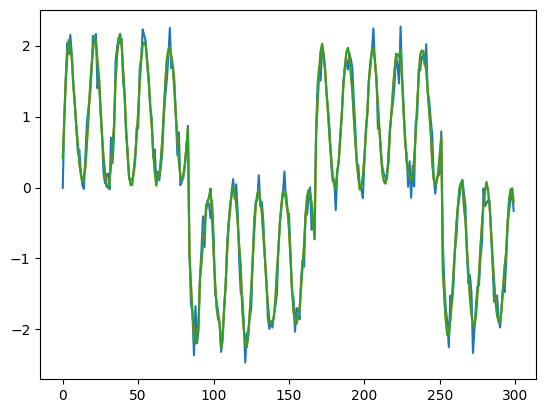

In [19]:
th = cores2ten(cores_h)
TTDf = TTD.full()
k = 300
plt.plot(tensor.reshape(-1,1)[:k])
plt.plot(th.reshape(-1,1)[:k])
plt.plot(TTDf.reshape(-1,1)[:k])